<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 50px 40px; border-radius: 20px; margin-bottom: 30px; box-shadow: 0 20px 60px rgba(102,126,234,0.3); position: relative; overflow: hidden;">
  <div style="position: absolute; top: -50px; right: -50px; width: 200px; height: 200px; background: rgba(255,255,255,0.05); border-radius: 50%;"></div>
  <div style="position: absolute; bottom: -30px; left: -30px; width: 150px; height: 150px; background: rgba(255,255,255,0.03); border-radius: 50%;"></div>
  <div style="position: relative; z-index: 1;">
    <div style="display: inline-block; background: rgba(255,255,255,0.15); padding: 6px 16px; border-radius: 20px; font-size: 0.85em; color: rgba(255,255,255,0.9); margin-bottom: 16px; backdrop-filter: blur(10px);">📘 CookBook Series</div>
    <h1 style="color: white; font-size: 2.8em; margin: 0 0 12px 0; font-weight: 700; letter-spacing: -0.02em; line-height: 1.2;">Урок 2 — Семплинг: temperature, top‑k, top‑p</h1>
    <p style="color: rgba(255,255,255,0.85); font-size: 1.15em; margin: 0 0 24px 0; line-height: 1.6;">Интуиция и реализация базовых методов семплинга на синтетических логитах с батч‑поддержкой и соответствием API NanoInfer (SamplingParams, greedy, nucleus). Практика + тесты инвариантов.</p>
    <div style="display: flex; gap: 20px; flex-wrap: wrap;">
      <span style="color: rgba(255,255,255,0.7); font-size: 0.9em;">📅 2026-03-17</span>
      <span style="color: rgba(255,255,255,0.7); font-size: 0.9em;">⏱ 45 мин</span>
      <span style="color: rgba(255,255,255,0.7); font-size: 0.9em;">👤 Автор: @Verbasik</span>
      <span style="color: rgba(255,255,255,0.7); font-size: 0.9em;">🟡 Средний</span>
    </div>
  </div>
</div>

<div style="background: linear-gradient(to right, #f8f9ff, #ffffff); border: 1px solid #e2e8f0; border-left: 5px solid #667eea; padding: 25px 30px; border-radius: 0 16px 16px 0; margin-bottom: 20px; box-shadow: 0 4px 15px rgba(0,0,0,0.04);">
  <h3 style="color: #667eea; margin: 0 0 16px 0; font-size: 1.3em; font-weight: 700;">📋 Содержание</h3>
  <div>
    <ol style="color: #4a5568; line-height: 2.2; margin: 0; padding-left: 20px;">
      <li><a href="#section-vvedenie-i-tseli" style="color: #667eea; text-decoration: none;">Введение и цели</a></li>
      <li><a href="#section-teoriya-semplinga" style="color: #667eea; text-decoration: none;">Интуиция и формализм семплинга</a></li>
      <li><a href="#section-sootvetstvie-minisglang" style="color: #667eea; text-decoration: none;">Соответствие NanoInfer</a></li>
      <li><a href="#section-realizaciya-api" style="color: #667eea; text-decoration: none;">Реализация API</a></li>
      <li><a href="#section-testy-i-invarianty" style="color: #667eea; text-decoration: none;">Тесты и инварианты</a></li>
      <li><a href="#section-demonstraciya" style="color: #667eea; text-decoration: none;">Демонстрация</a></li>
      <li><a href="#section-podvodnye-kamni" style="color: #667eea; text-decoration: none;">Подводные камни</a></li>
      <li><a href="#section-voprosy-samoproverki" style="color: #667eea; text-decoration: none;">Вопросы для самопроверки</a></li>
      <li><a href="#section-klyuchevye-vyvody" style="color: #667eea; text-decoration: none;">Ключевые выводы</a></li>
    </ol>
  </div>
</div>

<div style="background: #ebf8ff; border-left: 4px solid #63b3ed; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #2b6cb0; margin-bottom: 6px; font-size: 0.95em;">ℹ️ Мета</div>
  <div style="line-height: 1.7;">
    <div style="margin-bottom: 8px;">⏱ Время чтения: ~45 мин</div>
    <div style="margin-bottom: 8px;">🎯 Цель: реализовать базовые методы семплинга (temperature, top‑k, top‑p) с батч‑поддержкой и тестами (<code>SamplingParams</code>, greedy‑поведение)</div>
    <div>
      📋 Предварительные требования:
      <ul style="margin: 4px 0 0 20px; padding: 0;">
        <li>Урок 1 (токенизация)</li>
        <li>Базовый PyTorch</li>
        <li>Вероятности и softmax</li>
      </ul>
    </div>
  </div>
</div>

<div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 14px; padding: 24px 28px; margin: 20px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.04);">
  <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 16px;">
    <div style="width: 32px; height: 32px; background: linear-gradient(135deg, #667eea, #764ba2); border-radius: 8px; display: flex; align-items: center; justify-content: center; font-size: 0.9em;">💡</div>
    <h4 style="margin: 0; color: #2d3748; font-size: 1.15em; font-weight: 700;">Интуиция семплинга</h4>
  </div>
  <div style="color: #4a5568; line-height: 1.8; font-size: 0.97em;">
    Семплинг — это способ превратить логиты модели в конкретный следующий токен. Температура регулирует «остроту» распределения (насколько уверенно выбираем максимум), <em>top‑k</em> ограничивает выбор лучшими <em>k</em> кандидатами, а <em>top‑p</em> (nucleus) выбирает минимальное ядро токенов, покрывающее долю вероятности <em>p</em>. Вместе они позволяют балансировать между детерминизмом и разнообразием текста.
  </div>
</div>

## Семплинг в языковых моделях

### 1. Что такое логиты и зачем их превращать в вероятности

Языковая модель на каждом шаге генерации выдаёт вектор **логитов** — вещественных чисел, по одному на каждый токен в словаре. Словарь современных моделей содержит от 32 000 до 128 000 токенов, поэтому логиты — это просто длинный вектор $\mathbf{z} = (z_1, z_2, \ldots, z_V)$, где $V$ — размер словаря.

Логиты сами по себе не являются вероятностями: они могут быть отрицательными, больше единицы, и их сумма ничему особенному не равна. Чтобы превратить их в корректное вероятностное распределение, применяют функцию **softmax**:

$$P(w_i) = \frac{e^{z_i}}{\sum_{j=1}^{V} e^{z_j}}$$

Где:
- $w_i$ — $i$-й токен из словаря,
- $z_i$ — логит (сырой выход модели) для токена $w_i$,
- $V$ — размер словаря,
- $e^{z_i}$ — экспонента логита, гарантирующая положительность,
- знаменатель — нормировочная константа, приводящая сумму вероятностей к единице.

После этого все значения оказываются в диапазоне $(0, 1)$ и суммируются в единицу. Задача семплинга — выбрать один конкретный токен из этого распределения.

---

### 2. Температура

#### Интуиция

Представьте, что у вас есть «уверенность» модели — насколько резко одни токены доминируют над другими. Температура — это ручка, которая эту уверенность регулирует.

#### Формула

Температура $T > 0$ вводится непосредственно в softmax, делением логитов перед его применением:

$$P_T(w_i) = \frac{e^{z_i / T}}{\sum_{j=1}^{V} e^{z_j / T}}$$

Где:
- $T > 0$ — температура, единственный новый параметр по сравнению с обычным softmax,
- $z_i / T$ — масштабированный логит: при $T < 1$ логиты растут по модулю, при $T > 1$ — сжимаются.

#### Что происходит при разных значениях T

**При $T \to 0$** выражение $z_i / T$ уходит в бесконечность для максимального логита и в минус бесконечность для остальных. Распределение вырождается в дельта-функцию на токене-победителе:

$$\lim_{T \to 0} P_T(w_i) = \begin{cases} 1, & i = \arg\max_j z_j \\ 0, & \text{иначе} \end{cases}$$

Где:
- $\arg\max_j z_j$ — индекс токена с наибольшим логитом,
- результат — вырожденное распределение: вся вероятностная масса сосредоточена в одной точке.

Это **жадный (greedy) декодинг** — модель всегда выбирает наиболее вероятный токен.

**При $T = 1$** формула совпадает с обычным softmax — распределение такое, каким его обучили.

**При $T > 1$** деление на большое число сближает логиты друг к другу. Распределение становится более равномерным — «плоским». Модель начинает давать шанс маловероятным токенам, текст становится более разнообразным, но и менее связным.

#### Числовой пример

Пусть у нас три токена с логитами $\mathbf{z} = (3,\; 1,\; 0)$. Посчитаем вероятности при разных температурах:

| $T$ | $P(w_1)$ | $P(w_2)$ | $P(w_3)$ |
|-----|----------|----------|----------|
| 0.5 | 0.952 | 0.044 | 0.005 |
| 1.0 | 0.844 | 0.114 | 0.042 |
| 2.0 | 0.576 | 0.244 | 0.180 |

При низкой температуре первый токен подавляет всех. При высокой — шансы выравниваются.

---

### 3. Top-k семплинг

#### Идея

Даже при умеренной температуре в хвосте распределения могут оказаться тысячи токенов с крохотными, но ненулевыми вероятностями. Семплирование из этого «мусорного» хвоста порождает бессмысленные или случайные слова. Top-k решает эту проблему радикально: оставляем только $k$ лучших токенов, остальных выбрасываем.

### Формальное определение

Пусть $\mathcal{V}_k$ — множество $k$ токенов с наибольшими логитами:

$$\mathcal{V}_k = \{ \text{top-}k \text{ индексов по } z_i \}$$

Где:
- $k$ — гиперпараметр, задающий размер допустимого множества (типичные значения: 20–100),
- $\mathcal{V}_k$ — множество индексов $k$ токенов с наибольшими значениями $z_i$.

Тогда усечённое распределение:

$$P_k(w_i) = \begin{cases} \dfrac{e^{z_i}}{\sum_{j \in \mathcal{V}_k} e^{z_j}}, & i \in \mathcal{V}_k \\[6pt] 0, & \text{иначе} \end{cases}$$

Где:
- числитель $e^{z_i}$ — экспонента логита токена-кандидата,
- знаменатель $\sum_{j \in \mathcal{V}_k} e^{z_j}$ — нормировка только по выбранным $k$ токенам (не по всему словарю),
- токены вне $\mathcal{V}_k$ получают вероятность ровно $0$ и никогда не будут выбраны.

#### Проблема фиксированного k

Фиксированное $k$ плохо адаптируется к контексту:

- В ситуации, где следующий токен почти однозначен (например, после «Эйфелева...» явно следует «башня»), даже $k = 10$ — это слишком много.
- В ситуации с настоящей неопределённостью (начало предложения с открытым смыслом) $k = 10$ — слишком мало.

Именно это наблюдение мотивирует nucleus-семплинг.

---

### 4. Top-p (nucleus) семплинг

#### Идея

Вместо фиксированного числа токенов зафиксируем **суммарную вероятность**. Мы строим «ядро» — минимальное множество наиболее вероятных токенов, суммарная вероятность которых не меньше $p$.

#### Формальное определение

Отсортируем токены по убыванию вероятности (уже после softmax):

$$P(w_{(1)}) \geq P(w_{(2)}) \geq \ldots \geq P(w_{(V)})$$

Где:
- $w_{(i)}$ — токен, занявший $i$-е место в сортировке по убыванию вероятности,
- индекс в скобках $(i)$ обозначает порядковую статистику, а не исходный индекс токена в словаре.

Определим размер ядра $k^*$ как наименьшее целое такое, что:

$$\sum_{i=1}^{k^*} P(w_{(i)}) \geq p$$

Где:
- $p \in (0, 1]$ — порог накопленной вероятности (типичные значения: 0.9–0.95),
- $k^*$ — адаптивный размер ядра, который меняется от шага к шагу в зависимости от «уверенности» модели.

Ядро $\mathcal{V}_p = \{ w_{(1)}, w_{(2)}, \ldots, w_{(k^*)} \}$. Затем перенормируем:

$$P_p(w_i) = \begin{cases} \dfrac{P(w_i)}{\sum_{j \in \mathcal{V}_p} P(w_j)}, & i \in \mathcal{V}_p \\[6pt] 0, & \text{иначе} \end{cases}$$

Где:
- $P(w_i)$ — исходная вероятность токена из softmax,
- $\sum_{j \in \mathcal{V}_p} P(w_j)$ — суммарная вероятность ядра, на которую делится каждый токен для перенормировки (эта сумма $\geq p$, но обычно чуть больше, так как мы берём минимальное покрывающее множество).

#### Адаптивность ядра

Когда распределение острое (модель уверена), ядро маленькое — возможно, $k^* = 2$ или $3$ токена уже дают $p = 0.9$. Когда распределение плоское (модель не знает, что писать), ядро большое — может потребоваться $k^* = 500$ токенов, чтобы набрать те же $0.9$.

Это делает nucleus-семплинг **контекстно-адаптивным**: он автоматически расширяется там, где есть настоящая неопределённость, и сужается там, где ответ очевиден.

#### Числовой пример

Пусть распределение после softmax такое: $P = (0.6,\; 0.2,\; 0.1,\; 0.05,\; 0.03,\; \ldots)$.

При $p = 0.9$:
- После первого токена накоплено $0.6$ — мало.
- После второго: $0.6 + 0.2 = 0.8$ — мало.
- После третьего: $0.8 + 0.1 = 0.9$ — достигнуто.

Ядро: три токена. Перенормированные вероятности: $(0.667,\; 0.222,\; 0.111)$.

---

### 5. Как работает сам акт семплинга

После того как мы получили финальное распределение (с учётом температуры, top-k и/или top-p), нужно **выбрать один токен**. Это делается методом инверсии кумулятивной функции распределения (CDF sampling):

1. Выстроим токены с их вероятностями.
2. Вычислим кумулятивные суммы:

$$C_i = \sum_{j=1}^{i} P(w_j)$$

Где:
- $C_i$ — накопленная вероятность первых $i$ токенов (в порядке сортировки),
- $C_1 = P(w_1)$, $C_V = 1$ (последнее значение всегда равно единице).

3. Сгенерируем равномерное случайное число $u \sim \mathcal{U}(0, 1)$.
4. Выберем первый токен $w_i$, для которого $C_i \geq u$.

Этот алгоритм корректно реализует семплинг из любого дискретного распределения.

---

### 6. Совместное применение параметров

Температура, top-k и top-p не исключают друг друга — их применяют последовательно к одному и тому же вектору логитов:

$$\mathbf{z} \xrightarrow{\div T} \mathbf{z}/T \xrightarrow{\text{top-k}} \mathbf{z}^{(k)} \xrightarrow{\text{top-p}} \mathbf{z}^{(k,p)} \xrightarrow{\text{softmax}} \mathbf{P} \xrightarrow{\text{sample}} w$$

Где:
- $\mathbf{z}$ — исходный вектор логитов,
- $\mathbf{z}/T$ — логиты после масштабирования температурой,
- $\mathbf{z}^{(k)}$ — логиты после обнуления всех токенов вне top-k,
- $\mathbf{z}^{(k,p)}$ — логиты после дополнительного обнуления токенов вне nucleus,
- $\mathbf{P}$ — финальное вероятностное распределение после softmax,
- $w$ — выбранный токен.

Порядок важен: температуру применяют к логитам до softmax, top-k и top-p применяют либо к логитам (обнуляя ненужные), либо к вероятностям — результат эквивалентен.

#### Типичные рабочие настройки

| Задача | T | top-k | top-p |
|---|---|---|---|
| Точный ответ (код, факты) | 0.1–0.3 | — | — |
| Нейтральный текст | 0.7–1.0 | — | 0.9 |
| Творческое письмо | 1.0–1.2 | — | 0.95 |
| Максимальное разнообразие | 1.5+ | 50 | — |

---

### 7. Энтропия как мера «случайности» семплинга

Полезно иметь единую числовую характеристику того, насколько «случайно» поведёт себя модель. Для этого используют **энтропию Шеннона** распределения:

$$H = -\sum_{i=1}^{V} P(w_i) \log_2 P(w_i)$$

Где:
- $H$ — энтропия в битах,
- $P(w_i)$ — вероятность $i$-го токена,
- $\log_2 P(w_i)$ — отрицательная величина (так как $P \leq 1$), поэтому знак минус перед суммой делает $H \geq 0$,
- $V$ — размер словаря; слагаемые с $P(w_i) = 0$ по соглашению равны нулю (так как $\lim_{x \to 0} x \log x = 0$).

При greedy-декодинге ($T \to 0$) $H = 0$ — никакой неопределённости. При равномерном распределении по $V$ токенам $H = \log_2 V$ — максимальная неопределённость. Все механизмы семплинга — по сути, способы управления тем, где именно $H$ оказывается на этой шкале.

---

### 8. Связь с обучением модели

Важно понимать, что все эти параметры — **post-processing** над логитами. Сама модель обучается с фиксированной температурой $T = 1$ (или близкой к ней) с использованием кросс-энтропийного loss:

$$\mathcal{L} = -\sum_{t=1}^{T_{\text{seq}}} \log P(w_t \mid w_1, \ldots, w_{t-1})$$

Где:
- $\mathcal{L}$ — суммарный кросс-энтропийный лосс по всей последовательности,
- $T_{\text{seq}}$ — длина обучающей последовательности (не путать с температурой $T$),
- $w_t$ — токен на позиции $t$,
- $P(w_t \mid w_1, \ldots, w_{t-1})$ — вероятность, которую модель назначает правильному токену $w_t$ при условии всех предыдущих токенов,
- знак минус превращает логарифм вероятности (отрицательное число) в положительную величину потерь, которую минимизируют.

Таким образом, температура при инференсе — это «читерство» относительно обучения: мы сдвигаем распределение в сторону, которую модель не видела во время обучения. Слишком низкая температура делает модель более детерминированной, чем она «хочет» быть по своим весам, слишком высокая — добавляет шум сверх того, что было в обучающих данных.

---

### Итог

Три рычага семплинга решают одну задачу — управление компромиссом между **детерминизмом** и **разнообразием** — но с разных сторон: температура меняет форму всего распределения глобально, top-k жёстко ограничивает число кандидатов, а top-p делает это адаптивно, следуя за контекстом. В большинстве практических систем эти три параметра используют совместно, подбирая под конкретную задачу.

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-vvedenie-i-tseli" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">🎯</span> Введение и цели
</h2>

В этом уроке вы реализуете и проверите базовые стратегии семплинга, которые затем используются в планировщике:

- Температурное масштабирование логитов (включая greedy как предельный случай).
- Отсечение по <strong>top‑k</strong> и по <strong>top‑p</strong> (nucleus).
- Комбинация фильтров и нормализация вероятностей.
- Батч‑поддержка и совместимость интерфейсов с <code>SamplingParams</code>.

<div style="background: #f0fff4; border-left: 4px solid #48bb78; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #276749; margin-bottom: 6px; font-size: 0.95em;">✅ Результат</div>
  <div style="line-height: 1.7;">К концу урока у вас будет модуль семплинга с тестами инвариантов, API совместимым с <code>NanoInfer</code>, и демо на синтетических логитах.</div>
</div>

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-teoriya-semplinga" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">📐</span> Интуиция и формализм семплинга
</h2>

<div style="background: #faf5ff; border-left: 4px solid #b794f4; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #6b46c1; margin-bottom: 6px; font-size: 0.95em;">📐 Ключевая формула</div>
  <div style="line-height: 1.7;">
    Температурное масштабирование логитов:
    $$p_i = \frac{\exp(z_i / \tau)}{\sum_j \exp(z_j / \tau)}$$
    Где:
    <ul>
      <li>$z_i$ — логит токена $i$;</li>
      <li>$\tau$ — температура: чем меньше $\tau$, тем «острее» распределение; $\tau \to 0$ ведёт к greedy;</li>
      <li>$p_i$ — вероятность выбора токена $i$ после softmax.</li>
    </ul>
  </div>
</div>

<div style="background: #f8f9ff; border: 1px dashed #667eea; padding: 16px 20px; border-radius: 10px; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #667eea; margin-bottom: 6px; font-size: 0.95em;">🔗 См. также</div>
  <div style="line-height: 1.7;">Top‑k: оставить только токены с наибольшими <em>k</em> вероятностями (остальные занулить). Top‑p (nucleus): оставить минимальное множество токенов, чья суммарная вероятность ≥ <em>p</em>, остальное занулить.</div>
</div>

<div style="background: #fff5f5; border-left: 4px solid #fc8181; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #c53030; margin-bottom: 6px; font-size: 0.95em;">⚠️ Внимание</div>
  <div style="line-height: 1.7;">Top‑p без нижней границы <em>min_tokens_to_keep</em> может непреднамеренно оставить слишком мало токенов при «острых» распределениях. Всегда защищайтесь нижней границей.</div>
</div>

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-sootvetstvie-minisglang" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">🏗️</span> Соответствие NanoInfer
</h2>

- Соответствие <code>SamplingParams</code>: поля <code>temperature</code>, <code>top_k</code>, <code>top_p</code>, <code>ignore_eos</code>, <code>max_tokens</code>.
- Greedy: когда <code>temperature &le; 0</code> или <code>top_k == 1</code> и <code>top_p == 1.0</code>, выбираем <code>argmax</code>.
- Батч‑интерфейсы: логиты формы <code>[B, V]</code>, выход — индексы формы <code>[B]</code>.
- Совместимость типов: вероятности считаем в <code>float32</code>, индексы возвращаем как <code>int32</code> для согласования с остальным кодом.

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-realizaciya-api" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">🧰</span> Реализация API
</h2>

Ниже — импорт и константы, затем использование <code>SamplingParams</code> из NanoInfer с безопасным локальным fallback, и реализация функций семплинга.

<div style="background: #1a202c; color: #a0aec0; padding: 8px 16px; border-radius: 10px 10px 0 0; margin-bottom: -15px; font-family: 'Fira Code', monospace; font-size: 0.8em; display: flex; justify-content: space-between; align-items: center;">
  <span>🐍 nano-infer/python/infer/core.py</span>
  <span style="background: #2d3748; padding: 2px 10px; border-radius: 10px; font-size: 0.85em;">Python</span>
</div>

In [1]:
# ── Стандартная библиотека ──
import sys
from pathlib import Path
from typing  import Dict, Union
from typing  import Any, List, Optional, Tuple
from dataclasses import dataclass

# ── Сторонние библиотеки: ML ──
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from functools import lru_cache

# ── Сторонние библиотеки: визуализация ──
import matplotlib.pyplot as plt

# ── Константы модуля ──
EPS: float = 1e-8                        # Малое число для защиты от деления на ноль
MIN_TOKENS_TO_KEEP_DEFAULT: int = 1      # Низшая граница отбора токенов
DEFAULT_SEED: int = 42                   # Дет. seed для демонстраций
DEFAULT_MODEL_ID: str = "Qwen/Qwen3-8B"  # Модель по умолчанию для демонстраций
DEFAULT_MAX_LENGTH: int = 256            # Максимальная длина генерируемого текста по умолчанию
FALLBACK_MODEL_MAX_LENGTH: int = 512     # Максимальная длина генерируемого текста для резервной модели
DEFAULT_BATCH_SIZE: int = 32             # Размер батча по умолчанию

# ── Проверка доступности CUDA для корректных типов ──
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Комментарий: выбираем устройство CUDA при наличии для соответствия прод‑сценариям,
# но реализация ориентирована на CPU и работает на любом устройстве.

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 14px; padding: 24px 28px; margin: 20px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.04);">
  <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 16px;">
    <div style="width: 32px; height: 32px; background: linear-gradient(135deg, #667eea, #764ba2); border-radius: 8px; display: flex; align-items: center; justify-content: center; font-size: 0.9em;">🧰</div>
    <h4 style="margin: 0; color: #2d3748; font-size: 1.15em; font-weight: 700;">Подготовка окружения инференса: dtype и загрузка модели</h4>
  </div>
</div>

<div style="background: #1a202c; color: #a0aec0; padding: 8px 16px; border-radius: 10px 10px 0 0; margin-bottom: -15px; font-family: 'Fira Code', monospace; font-size: 0.8em; display: flex; justify-content: space-between; align-items: center;">
  <span>🐍 🐍 based on runtime loading: utils/hf.py + models/weight.py + engine/engine.py</span>
  <span style="background: #2d3748; padding: 2px 10px; border-radius: 10px; font-size: 0.85em;">Python</span>
</div>


In [2]:
def _choose_dtype(dtype: Optional[str]) -> torch.dtype:
    """
    Description:
    ---------------
        Подбирает torch.dtype на основании пользовательского значения.
        При значении "auto" выбирается безопасный режим:
        - на CUDA предпочитается bfloat16, если поддерживается;
        - иначе используется float16;
        - на CPU используется float32 для устойчивости вычислений.

    Args:
    ---------------
        dtype: Строковое обозначение типа данных. 
        Поддерживаются:
            "auto", "fp32", "float32", "bf16", "bfloat16",
            "fp16", "float16". 
        Если передано неизвестное значение, используется torch.float32.

    Returns:
    ---------------
        Объект torch.dtype, соответствующий выбранному режиму.

    Raises:
    ---------------
        Не выбрасывает исключения явно. 
        При неизвестном значении dtype используется torch.float32.
    """
    if dtype is None or dtype == "auto":
        if torch.cuda.is_bf16_supported(): return torch.bfloat16
        if torch.cuda.is_available(): return torch.float16

        return torch.float32

    mapping: Dict[str, torch.dtype] = {
        "fp32":     torch.float32,
        "float32":  torch.float32,
        "bf16":     torch.bfloat16,
        "bfloat16": torch.bfloat16,
        "fp16":     torch.float16,
        "float16":  torch.float16,
    }

    return mapping.get(dtype.lower(), torch.float32)

# Декоратор кеширования вызова функции
@lru_cache(maxsize=2)
def _cached_load_model_and_tokenizer(model_id: str, torch_dtype: torch.dtype, device: str):
    """
    Description:
    ---------------
        Внутренняя функция для загрузки токенизатора и модели с кэшированием.
        Использует @lru_cache для предотвращения повторной загрузки весов модели
        при одинаковых входных параметрах (model_id, dtype, device).

        Особенности загрузки:
        - Автоматически устанавливает pad_token равным eos_token, если pad_token не задан;
        - Переводит модель в режим eval();
        - Использует device_map="auto" для распределения слоев по устройствам при работе с CUDA.

    Args:
    ---------------
        model_id: Идентификатор модели Hugging Face.
        torch_dtype: Тип данных torch.dtype для загрузки весов модели.
        device: Строковое обозначение устройства ("cuda" или "cpu").

    Returns:
    ---------------
        Кортеж из двух объектов:
        - tok: загруженный токенизатор (AutoTokenizer);
        - model: загруженная модель (AutoModelForCausalLM) в режиме eval.

    Raises:
    ---------------
        OSError: Может быть выброшено при отсутствии доступа к модели или проблемах с кэшем.
        RuntimeError: Может возникнуть при ошибке инициализации модели в transformers.
    
    Note:
    ---------------
        Функция предназначена только для внутреннего использования через load_model_and_tokenizer.
        Кэш ограничен 2 записями (maxsize=2) для поддержки быстрого переключения между 
        двумя конфигурациями (например, разные модели или типы данных).
    """
    # Загрузка токенизатора
    tok = AutoTokenizer.from_pretrained(model_id)
    
    # Fallback: если у токенизатора не задан pad_token — используем EOS
    if getattr(tok, 'pad_token_id', None) is None and getattr(tok, 'eos_token', None) is not None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch_dtype,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()

    return tok, model


def load_model_and_tokenizer(
    model_id: Optional[str] = None,
    *,
    dtype: Optional[str] = "auto",
    device: Optional[str] = None,
) -> Tuple[Any, Any]:
    """
    Description:
    ---------------
        Загружает токенизатор и causal language model для указанной модели.

        Поведение функции:
        - если model_id не указан, используется DEFAULT_MODEL_ID;
        - если device не указан, автоматически выбирается "cuda" или "cpu";
        - если доступна CUDA, используется device_map="auto";
        - модель переводится в режим eval().

    Args:
    ---------------
        model_id: Идентификатор модели Hugging Face.
        dtype: Предпочтительный тип данных для модели.
        device: Явное устройство выполнения, например "cpu" или "cuda".

    Returns:
    ---------------ы
        Кортеж из двух объектов:
        - tok: токенизатор модели;
        - model: загруженная causal language model.

    Raises:
    ---------------
        RuntimeError: Может быть выброшено библиотекой transformers
            при невозможности загрузить модель или токенизатор.
        OSError: Может быть выброшено при проблемах доступа к модели
            или локальному кэшу.

    Examples:
    ---------------
        >>> tok, model = load_model_and_tokenizer(model_id="gpt2")
        >>> tok is not None
        True
    """
    model_id = model_id or DEFAULT_MODEL_ID
    torch_dtype = _choose_dtype(dtype)

    # Автоматически выбираем устройство, чтобы не заставлять пользователя
    # вручную указывать CPU/GPU в типовом демонстрационном сценарии.
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Кэшируем загрузку модели/токенизатора, чтобы не перезагружать веса для каждого теста
    tok, model = _cached_load_model_and_tokenizer(model_id, torch_dtype, device)
    
    return tok, model


@torch.inference_mode()
def get_last_token_logits(
    prompts: List[str],
    *,
    model_id: Optional[str] = None,
    dtype: Optional[str] = "auto",
    device: Optional[str] = None,
) -> Tuple[torch.Tensor, int, int]:
    """
    Description:
    ---------------
        Возвращает логиты последней позиции входной последовательности
        для каждого промпта из списка.

        Формат результата:
        - logits: тензор формы [B, V], где:
            B — размер батча,
            V — размер словаря;
        - eos_token_id: идентификатор токена конца последовательности;
        - vocab_size: размер словаря модели.

    Args:
    ---------------
        prompts: Список входных текстовых промптов.
        model_id: Идентификатор модели Hugging Face.
        dtype: Предпочтительный dtype модели.
        device: Устройство выполнения.

    Returns:
    ---------------
        Кортеж из трёх элементов:
        - last_logits: torch.Tensor формы [B, V];
        - eos_id: int, идентификатор EOS-токена или -1;
        - vocab_size: int, размер словаря.

    Raises:
    ---------------
        RuntimeError: Может возникнуть при ошибке инференса модели.
        ValueError: Может косвенно возникнуть на стороне tokenizer/model
                    при некорректных входных данных.

    Examples:
    ---------------
        >>> logits, eos_id, vocab_size = get_last_token_logits(
        ...     ["Привет!", "Hello!"],
        ...     model_id="gpt2"
        ... )
        >>> logits.ndim
        2
    """
    tok, model = load_model_and_tokenizer(
        model_id=model_id,
        dtype=dtype,
        device=device,
    )

    model_max_length = getattr(tok, "model_max_length", FALLBACK_MODEL_MAX_LENGTH)
    max_length = min(DEFAULT_MAX_LENGTH, model_max_length)

    batch = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length,
    )

    if torch.cuda.is_available():
        # Переносим батч на устройство параметров модели, если оно известно и не CPU.
        try:
            dev = next(model.parameters()).device
        except StopIteration:
            # Модель не имеет параметров
            dev = None

        # Если модель на GPU, перемещаем батч туда же
        if dev is not None and getattr(dev, 'type', 'cpu') != 'cpu':
            batch = {k: v.to(dev) for k, v in batch.items()}

    # Получаем логиты последней позиции для каждого промпта
    out = model(**batch)
    logits = out.logits
    # Логиты последней позиции: [B, V]
    last_logits = logits[:, -1, :].detach()

    # На CPU приводим к float32 для стабильности последующих операций.
    if not torch.cuda.is_available():
        last_logits = last_logits.to(torch.float32)

    eos_id = tok.eos_token_id if tok.eos_token_id is not None else -1
    vocab_size = last_logits.shape[-1]

    return last_logits, int(eos_id), int(vocab_size)


@torch.inference_mode()
def get_demo_batch_logits(
    *,
    model_id: Optional[str] = None,
    prompts: Optional[List[str]] = None,
    batch_size: int = DEFAULT_BATCH_SIZE,
    dtype: Optional[str] = "auto",
    device: Optional[str] = None,
) -> Tuple[torch.Tensor, int, int]:
    """
    Description:
    ---------------
        Обёртка для демонстраций: подготавливает небольшой набор
        смешанных русско-английских промптов, при необходимости
        повторяет их до нужного размера батча и возвращает логиты вида
        [B, V], а также eos_id и vocab_size.

    Args:
    ---------------
        model_id: Идентификатор модели Hugging Face.
        prompts: Пользовательский список промптов.
        batch_size: Требуемый размер батча.
        dtype: Предпочтительный dtype модели.
        device: Устройство выполнения.

    Returns:
    ---------------
        Кортеж из трёх элементов:
        - тензор логитов формы [B, V];
        - идентификатор EOS-токена;
        - размер словаря модели.

    Raises:
    ---------------
        RuntimeError: Может возникнуть при ошибке загрузки модели
            или выполнении инференса.
        ValueError: Может возникнуть косвенно при некорректном размере
            батча или проблемах токенизации.

    Examples:
    ---------------
        >>> logits, eos_id, vocab_size = get_demo_batch_logits(
        ...     model_id="gpt2",
        ...     batch_size=4
        ... )
        >>> logits.shape[0]
        4
    """
    base_prompts = prompts or [
        "Привет! Расскажи коротко про семплинг.",
        "Hello, give me a short poem.",
        "Compute 2+2 and explain.",
        "Кратко: что такое вероятности софтмакса?",
        "What is top-k vs top-p?",
        "Сделай список из 3 пунктов.",
        "Name three colors.",
        "Почему greedy детерминирован?",
    ]

    # Повторяем список промптов до batch_size
    if len(base_prompts) < batch_size:
        # Вычисляем, сколько раз нужно повторить базовый список, чтобы покрыть batch_size
        reps = (batch_size + len(base_prompts) - 1) // len(base_prompts)
        # Создаём новый список, повторяя базовые промпты нужное количество раз и обрезая до batch_size
        tiled = (base_prompts * reps)[:batch_size]
    else:
        tiled = base_prompts[:batch_size]

    return get_last_token_logits(
        tiled,
        model_id=model_id,
        dtype=dtype,
        device=device,
    )

<div style="background: #1a202c; color: #a0aec0; padding: 8px 16px; border-radius: 10px 10px 0 0; margin-bottom: -15px; font-family: 'Fira Code', monospace; font-size: 0.8em; display: flex; justify-content: space-between; align-items: center;">
  <span>🐍 nano-infer/python/infer/core.py</span>
  <span style="background: #2d3748; padding: 2px 10px; border-radius: 10px; font-size: 0.85em;">Python</span>
</div>

In [3]:
"""
Создание SamplingParams
"""

@dataclass
class SamplingParams:
    """
    Description:
    ---------------
        Эквивалент параметров семплинга из NanoInfer для локального
        использования в ноутбуке. Поля и семантика совпадают.

    Args:
    ---------------
        temperature: Температура; <= 0.0 означает greedy.
        top_k: Ограничение по количеству лучших токенов; ≤ 0 отключает.
        top_p: Ядро вероятности (0..1]; 1.0 отключает.
        ignore_eos: Игнорировать ли EOS при семплинге.
        max_tokens: Бюджет токенов (используется в декод‑цикле).

    Returns:
    ---------------
        Экземпляр параметров семплинга.

    Raises:
    ---------------
        ValueError: При некорректных значениях полей.

    Examples:
    ---------------
        >>> sp = SamplingParams(temperature=0.7, top_k=50, top_p=0.9)
        >>> isinstance(sp, SamplingParams)
        True
    """

    temperature: float = 0.0  # Температура; <= 0 → greedy
    top_k: int = -1           # K лучших; ≤ 0 → без top-k
    top_p: float = 1.0        # Ядро вероятности; 1.0 → без top-p
    ignore_eos: bool = False  # Игнорировать EOS при выборе
    max_tokens: int = 1024    # Максимум токенов в ответе

    @property
    def is_greedy(self) -> bool:
        """
        Description:
        ---------------
            Возвращает True, если параметрами задан greedy-режим,
            то есть температура не положительна или top-k=1 и top-p=1.

        Args:
        ---------------
            None

        Returns:
        ---------------
            bool: Признак greedy.

        Raises:
        ---------------
            Ничего не выбрасывает.

        Examples:
        ---------------
            >>> SamplingParams().is_greedy
            True
        """
        return (
            (self.temperature <= 0.0 or self.top_k == 1) and self.top_p == 1.0
        )

    def __post_init__(self) -> None:
        """
        Валидация и нормализация полей.
        - top_k: ≤ 0 отключает фильтр
        - top_p: (0, 1]
        - max_tokens: ≥ 1
        """
        # Нормализуем top_k: 0 трактуем как отключение
        if self.top_k == 0:
            self.top_k = -1
        if self.top_k < -1 or (self.top_k not in (-1,) and self.top_k < 1):
            raise ValueError("top_k должен быть -1 (отключено) или ≥ 1")
        if not (0.0 < float(self.top_p) <= 1.0):
            raise ValueError("top_p должен быть в (0, 1]")
        if int(self.max_tokens) < 1:
            raise ValueError("max_tokens должен быть ≥ 1")

<div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 14px; padding: 24px 28px; margin: 20px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.04);">
  <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 16px;">
    <div style="width: 32px; height: 32px; background: linear-gradient(135deg, #667eea, #764ba2); border-radius: 8px; display: flex; align-items: center; justify-content: center; font-size: 0.9em;">🧮</div>
    <h4 style="margin: 0; color: #2d3748; font-size: 1.15em; font-weight: 700;">Семплинговые примитивы: температура, маски, top‑k/top‑p</h4>
  </div>
</div>

<div style="background: #1a202c; color: #a0aec0; padding: 8px 16px; border-radius: 10px 10px 0 0; margin-bottom: -15px; font-family: 'Fira Code', monospace; font-size: 0.8em; display: flex; justify-content: space-between; align-items: center;">
  <span>🐍 based on: nano-infer/python/infer/engine/sample.py — температура, маски, top‑k/top‑p</span>
  <span style="background: #2d3748; padding: 2px 10px; border-radius: 10px; font-size: 0.85em;">Python</span>
</div>


In [4]:
def apply_temperature(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    """
    Description:
    ---------------
        Применяет температурное масштабирование к логитам. При
        temperature <= 0.0 возвращает исходные логиты (greedy-путь).

    Args:
    ---------------
        logits: Тензор логитов формы [B, V] или [V].
        temperature: Положительное число, если <= 0.0 трактуется как greedy.

    Returns:
    ---------------
        torch.Tensor: Масштабированные логиты той же формы и типа.

    Raises:
    ---------------
        TypeError: Если вход не является тензором Torch.

    Examples:
    ---------------
        >>> z = torch.tensor([[1.0, 2.0]])
        >>> apply_temperature(z, 2.0).shape
        torch.Size([1, 2])
    """
    if not isinstance(logits, torch.Tensor):
        raise TypeError("logits должен быть torch.Tensor")
    
    # Greedy режим — возвращаем как есть
    if temperature <= 0.0:
        # Без изменений
        return logits
    
    # Обратная температура
    inv_tau: float = 1.0 / max(temperature, EPS)
    
    # Масштабируем логиты
    return logits * inv_tau


def mask_token_ids(
    logits: torch.Tensor, token_ids: Optional[List[int]]
) -> torch.Tensor:
    """
    Description:
    ---------------
        Присваивает -inf (минус бесконечность) логитам указанных токенов (маскирование).

    Args:
    ---------------
        logits: Тензор логитов формы [B, V].
        token_ids: Список токенов для маскирования или None.

    Returns:
    ---------------
        torch.Tensor: Логиты с замаскированными токенами.

    Raises:
    ---------------
        ValueError: Если форма логитов не двумерная.

    Examples:
    ---------------
        >>> z = torch.zeros((2, 5))
        >>> mask_token_ids(z, [0]).shape
        torch.Size([2, 5])
    """
    # Проверяем, что батчевые логиты [B, V]
    if logits.ndim != 2:
        raise ValueError("Ожидается logits формы [B, V]")
    
    # Если список пуст или None
    if not token_ids:
        return logits
    
    # Копируем, чтобы не портить вход
    out = logits.clone()
    
    # Идём по токенам для маскирования
    for tid in token_ids:
        # Маскируем -inf
        out[:, int(tid)] = -torch.inf
    
    return out


def filter_top_k(
    logits: torch.Tensor, k: int, min_tokens_to_keep: int = MIN_TOKENS_TO_KEEP_DEFAULT
) -> torch.Tensor:
    """
    Description:
    ---------------
        Оставляет только top-k токенов по логитам в каждой строке, остальные
        логиты становятся -inf. Гарантирует минимум min_tokens_to_keep.

    Args:
    ---------------
        logits: Тензор логитов формы [B, V].
        k: Число сохраняемых токенов, k <= 0 отключает фильтр.
        min_tokens_to_keep: Нижняя граница сохраняемых токенов.

    Returns:
    ---------------
        torch.Tensor: Логиты с -inf вне top-k ядра.

    Raises:
    ---------------
        ValueError: Если вход не двумерный.

    Examples:
    ---------------
        >>> z = torch.randn(2, 5)
        >>> out = filter_top_k(z, 2)
        >>> torch.isfinite(out).sum(dim=1).min().item() >= 2
        True
    """
    if logits.ndim != 2:
        raise ValueError("Ожидается logits формы [B, V]")
    
    bsz, vocab = logits.shape
    
    if k <= 0:
        return logits
    
    # Эффективный k с учётом размера словаря и минимума токенов
    k_eff: int = max(min(k, vocab), min_tokens_to_keep)

    # Получаем ИНДЕКСЫ top-k токенов (точно k штук)
    _, topk_indices = torch.topk(logits, k_eff, dim=1)
    
    # Создаём маску и заполняем -inf везде
    out = torch.full_like(logits, -torch.inf)
    
    # Разрешаем только top-k токенам по индексам
    out.scatter_(1, topk_indices, logits.gather(1, topk_indices))
    
    return out


def filter_top_p(
    probs: torch.Tensor, p: float, min_tokens_to_keep: int = MIN_TOKENS_TO_KEEP_DEFAULT
) -> torch.Tensor:
    """
    Description:
    ---------------
        Оставляет минимальное множество токенов (по убыванию вероятности),
        чья суммарная вероятность ≥ p. Остальные зануляются. Гарантирует
        минимум min_tokens_to_keep.

    Args:
    ---------------
        probs: Вероятности формы [B, V], строки суммируются в 1.
        p: Порог ядра (0 < p ≤ 1). p>=1.0 отключает фильтр.
        min_tokens_to_keep: Нижняя граница сохраняемых токенов.

    Returns:
    ---------------
        torch.Tensor: Вероятности с нулями вне nucleus и перенормировкой.

    Raises:
    ---------------
        ValueError: Если probs не двумерный или содержит отрицательные.

    Examples:
    ---------------
        >>> p = torch.softmax(torch.randn(2, 5), dim=1)
        >>> out = filter_top_p(p, 0.9)
        >>> (out.sum(dim=1) - 1.0).abs().max().item() < 1e-5
        True
    """
    if probs.ndim != 2:
        raise ValueError("Ожидается probs формы [B, V]")
    if p >= 1.0:
        return probs
    if (probs < 0).any():
        raise ValueError("Вероятности должны быть неотрицательны")

    # Сортируем вероятности по убыванию для nucleus
    sorted_probs, sorted_idx = torch.sort(probs, dim=1, descending=True)  # Сортировка
    cumsum = torch.cumsum(sorted_probs, dim=1)                            # Кумулятивная сумма по строке
    # Маска ядер: берём минимум токенов, набирающих порог p
    keep_mask = cumsum - sorted_probs < p                                 # Истина для элементов внутри ядра
    # Гарантируем минимум токенов
    keep_min = torch.zeros_like(keep_mask)                                # Пустая маска
    keep_min[:, : max(min_tokens_to_keep, 1)] = True                      # Оставляем минимум
    keep_mask = torch.logical_or(keep_mask, keep_min)                     # Объединяем условия
    # Возвращаем маску к исходному порядку индексов
    inv_idx = torch.argsort(sorted_idx, dim=1)                            # Индексы для обратной перестановки
    original_mask = torch.gather(keep_mask, 1, inv_idx)                   # Маска в исходном порядке
    # Обнуляем вероятности вне ядра и перенормируем строки
    masked = torch.where(original_mask, probs, torch.zeros_like(probs))   # Нули вне ядра
    row_sums = masked.sum(dim=1, keepdim=True).clamp_min(EPS)             # Суммы по строке
    renorm = masked / row_sums                                            # Перенормировка до суммы 1
    
    return renorm


def prepare_probs(
    logits: torch.Tensor,
    temperature: float,
    top_k: int,
    top_p: float,
    ignore_eos_id: Optional[int] = None,
    min_tokens_to_keep: int = MIN_TOKENS_TO_KEEP_DEFAULT,
) -> torch.Tensor:
    """
    Description:
    ---------------
        Готовит вероятности для семплинга: опционально маскирует EOS,
        применяет температуру, затем top-k (если задан), затем softmax,
        затем top-p (если задан) с перенормировкой строк.

    Args:
    ---------------
        logits: Логиты формы [B, V].
        temperature: Температура; <= 0.0 допускает greedy-ветку позже.
        top_k: Параметр top-k; <= 0 отключает.
        top_p: Параметр top-p; >= 1.0 отключает.
        ignore_eos_id: Если задан, маскируем EOS перед softmax.
        min_tokens_to_keep: Нижняя граница сохраняемых токенов.

    Returns:
    ---------------
        torch.Tensor: Вероятности формы [B, V], строки суммируются в 1.

    Raises:
    ---------------
        ValueError: Если вход не формы [B, V].

    Examples:
    ---------------
        >>> z = torch.randn(2, 5)
        >>> p = prepare_probs(z, 1.0, 0, 1.0)
        >>> (p.sum(dim=1) - 1.0).abs().max().item() < 1e-5
        True
    """
    if logits.ndim != 2:
        raise ValueError("Ожидается logits формы [B, V]")
    
    # Ссылка на входные логиты
    work = logits

    if ignore_eos_id is not None:                               # Если нужно игнорировать EOS
        work = mask_token_ids(work, [int(ignore_eos_id)])       # Маскируем EOS
    
    work = apply_temperature(work, temperature)                 # Применяем температуру
    
    # При необходимости применяем top‑k (к логитам)
    if top_k > 0:
        work = filter_top_k(work, top_k, min_tokens_to_keep)    # Маскируем логиты
    
    # Единственный softmax после возможного top‑k
    probs = torch.softmax(work.float(), dim=1)                  # Softmax в float32
    
    # При необходимости применяем top‑p
    if top_p < 1.0:
        probs = filter_top_p(probs, top_p, min_tokens_to_keep)  # Фильтр nucleus
    
    return probs


def sample_from_probs(
    probs: torch.Tensor, generator: Optional[torch.Generator] = None
) -> torch.Tensor:
    """
    Description:
    ---------------
        Семплирует один токен на строку из распределения вероятностей.

    Args:
    ---------------
        probs: Вероятности формы [B, V], строки суммируются в 1.
        generator: Опционально — источник случайности Torch.

    Returns:
    ---------------
        torch.Tensor: Индексы токенов формы [B] (dtype=int32).

    Raises:
    ---------------
        ValueError: Если probs не формы [B, V].

    Examples:
    ---------------
        >>> p = torch.tensor([[0.1, 0.9]], dtype=torch.float32)
        >>> idx = sample_from_probs(p)
        >>> idx.shape
        torch.Size([1])
    """
    if probs.ndim != 2:
        raise ValueError("Ожидается probs формы [B, V]")
    
    # Если передан генератор, но он не на том же устройстве — используем fallback
    if generator is not None:
        gen_dev = getattr(generator, 'device', None)
        if gen_dev is None or gen_dev != probs.device:
            generator = None  # fallback: использовать глобальный генератор устройства
    
    # Обычный рандом в пространстве [0, 1)
    # Визуально (пример):
    # probs = [0.1, 0.3, 0.4, 0.2]  # сумма = 1.0

    # Накопленная сумма (CDF):
    # cdf = [0.1, 0.4, 0.8, 1.0]
    #     ↑    ↑    ↑    ↑
    #     |    |    |    └─ token_3 (20%)
    #     |    |    └────── token_2 (40%)
    #     |    └─────────── token_1 (30%)
    #     └──────────────── token_0 (10%)

    # Генератор выдаёт случайное число в [0, 1], например: 0.65
    #                                                         ↓
    # cdf = [0.1, 0.4, 0.8, 1.0]  → первый ≥ 0.65 это 0.8 → выбираем token_2 ✓
    idx = torch.multinomial(probs, 1, replacement=True, generator=generator)

    return idx.view(-1).to(torch.int32)


def sample_logits(
    logits: torch.Tensor,
    params: SamplingParams,
    vocab_size: Optional[int] = None,
    ignore_eos_id: Optional[int] = None,
    generator: Optional[torch.Generator] = None,
) -> torch.Tensor:
    """
    Description:
    ---------------
        Единая точка входа: семплирует индексы токенов из логитов
        согласно параметрам семплинга. Поддерживает greedy.

    Args:
    ---------------
        logits: Тензор логитов формы [B, V].
        params: Параметры семплинга (совместимы с NanoInfer).
        vocab_size: Размер словаря (необязательно; для проверок).
        ignore_eos_id: При необходимости — ID EOS для маскирования.
        generator: Источник случайности Torch.

    Returns:
    ---------------
        torch.Tensor: Индексы выбранных токенов формы [B] (int32).

    Raises:
    ---------------
        ValueError: Если форма логитов неверна.

    Examples:
    ---------------
        >>> z = torch.randn(4, 10)
        >>> idx = sample_logits(z, SamplingParams(temperature=0.7, top_p=0.9))
        >>> idx.shape
        torch.Size([4])
    """
    if logits.ndim != 2:
        raise ValueError("Ожидается logits формы [B, V]")
    if vocab_size is not None:
        assert logits.shape[1] == int(vocab_size), "Несоответствие vocab_size"
    if getattr(params, "is_greedy", False):
        # Выбираем argmax по каждой строке
        greedy_idx = torch.argmax(logits, dim=1)  # Индексы максимумов
        return greedy_idx.to(torch.int32)         # Приводим тип к int32
    
    # Готовим вероятности с учётом температуры и фильтров
    probs = prepare_probs(
        logits,
        params.temperature,
        params.top_k,
        params.top_p,
        ignore_eos_id=ignore_eos_id if params.ignore_eos else None,
        min_tokens_to_keep=MIN_TOKENS_TO_KEEP_DEFAULT,
    )
    # Семплируем из распределения вероятностей
    return sample_from_probs(probs, generator=generator)  # Индексы [B]


<div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 14px; padding: 24px 28px; margin: 20px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.04);">
  <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 16px;">
    <div style="width: 32px; height: 32px; background: linear-gradient(135deg, #667eea, #764ba2); border-radius: 8px; display: flex; align-items: center; justify-content: center; font-size: 0.9em;">✅</div>
    <h4 style="margin: 0; color: #2d3748; font-size: 1.15em; font-weight: 700;">Тесты инвариантов семплинга</h4>
  </div>
</div>

<div style="background: #1a202c; color: #a0aec0; padding: 8px 16px; border-radius: 10px 10px 0 0; margin-bottom: -15px; font-family: 'Fira Code', monospace; font-size: 0.8em; display: flex; justify-content: space-between; align-items: center;">
  <span>🐍 notebook-only tests</span>
  <span style="background: #2d3748; padding: 2px 10px; border-radius: 10px; font-size: 0.85em;">Python</span>
</div>


In [5]:
def test_greedy_selects_argmax() -> None:
    """
    Description:
    ---------------
        Проверяет, что в greedy-режиме выбирается argmax для каждой
        строки логитов.

    Raises:
    ---------------
        AssertionError: Если выбор не совпал с argmax.
    """
    z, _, vocab_size = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=2)
    params = SamplingParams(temperature=0.0, top_k=-1, top_p=1.0)
    idx = sample_logits(z, params)
    expected = torch.argmax(z, dim=1).to(torch.int32)

    # Наглядный вывод для отладки
    print("—— Greedy: argmax поведение ——")
    print(f"Batch size: {z.shape[0]}, Vocab size: {vocab_size}")
    for b in range(z.shape[0]):
        top_5_logits, top_5_idx = torch.topk(z[b], k=5)
        print(f"  Batch {b}: top-5 logits = {top_5_logits.tolist()}")
        print(f"             top-5 indices = {top_5_idx.tolist()}")
        print(f"             selected = {idx[b].item()}, expected (argmax) = {expected[b].item()}")

    # Проверка
    match = torch.equal(idx, expected)
    print(f"✓ Match: {match}")
    assert match, "Greedy должен выбирать argmax"


def test_top_k_prunes_and_keeps_minimum() -> None:
    """
    Description:
    ---------------
        Проверяет, что filter_top_k оставляет не менее заданного минимума
        токенов и правильно маскирует остальные.

    Raises:
    ---------------
        AssertionError: При нарушении инвариантов.
    """
    z, _, vocab_size = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=4)
    pruned = filter_top_k(z, k=3, min_tokens_to_keep=2)
    kept = torch.isfinite(pruned).sum(dim=1)

    # Наглядный вывод
    print("—— Top-k: маска и минимум сохраняемых ——")
    print(f"Batch size: {z.shape[0]}, Vocab size: {vocab_size}")
    print(f"Top-k filter: k=3, min_tokens_to_keep=2")
    for b in range(z.shape[0]):
        finite_count = int(kept[b])
        top_logits, top_idx = torch.topk(z[b], k=5)
        print(f"  Batch {b}: kept finite logits = {finite_count}, top-5 unfiltered = {top_idx.tolist()}")
    
    print(f"  Min kept across batch: {int(kept.min())}")
    assert int(kept.min()) >= 2, "Должны сохранить минимум 2 токена"
    assert int(kept.max()) <= 3, "Должны сохранить максимум 3 токена"
    print("✓ Pass")


def test_top_p_nucleus_sampling() -> None:
    """
    Description:
    ---------------
        Проверяет, что filter_top_p правильно отбирает токены по
        cumulative probability с корректной перенормировкой.

    Raises:
    ---------------
        AssertionError: При нарушении инвариантов вероятностей.
    """
    torch.manual_seed(DEFAULT_SEED)
    z, _, vocab_size = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=2)
    probs = torch.softmax(z, dim=1)
    filtered = filter_top_p(probs, p=0.9, min_tokens_to_keep=2)

    # Наглядный вывод
    print("—— Top-p: nucleus sampling ——")
    print(f"Batch size: {probs.shape[0]}, Vocab size: {vocab_size}")
    print(f"Nucleus threshold: p=0.9")
    for b in range(probs.shape[0]):
        kept_mask = torch.isfinite(filtered[b])
        kept_count = int(kept_mask.sum())
        kept_prob_sum = filtered[b][kept_mask].sum().item()
        top_logits, top_idx = torch.topk(z[b], k=5)
        print(f"  Batch {b}: kept {kept_count} tokens, cumsum_prob ≈ {kept_prob_sum:.3f}")
        print(f"           top-5 indices = {top_idx.tolist()}")
    
    # Проверка: все строки суммируются в 1 (или близко)
    sums = filtered.sum(dim=1)
    assert (sums - 1.0).abs().max() < 1e-4, "Probability sums должны быть ≈ 1"
    print("✓ Probabilities renormalized correctly")


def test_batch_independence() -> None:
    """
    Description:
    ---------------
        Проверяет, что фильтрация происходит независимо для каждой
        строки батча (один элемент батча не влияет на другой).

    Raises:
    ---------------
        AssertionError: Если фильтрация не независима.
    """
    torch.manual_seed(DEFAULT_SEED)
    z, _, vocab_size = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=3)
    
    # Фильтруем батч целиком
    batch_filtered = filter_top_k(z, k=5, min_tokens_to_keep=1)
    
    # Фильтруем каждый элемент отдельно
    individual_filtered = []
    for b in range(z.shape[0]):
        single = z[b:b+1]  # [1, V]
        filtered_single = filter_top_k(single, k=5, min_tokens_to_keep=1)
        individual_filtered.append(filtered_single)
    individual_filtered = torch.cat(individual_filtered, dim=0)

    # Наглядный вывод
    print("—— Batch independence ——")
    print(f"Batch size: {z.shape[0]}, Vocab size: {vocab_size}")
    matches = torch.equal(batch_filtered, individual_filtered)
    print(f"Batch filtering == individual filtering: {matches}")
    
    for b in range(z.shape[0]):
        batch_kept = torch.isfinite(batch_filtered[b]).sum().item()
        indiv_kept = torch.isfinite(individual_filtered[b]).sum().item()
        print(f"  Batch {b}: batch kept={int(batch_kept)}, individual kept={int(indiv_kept)}")
    
    assert matches, "Батч и индивидуальная фильтрация должны совпадать"
    print("✓ Pass")

<div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 14px; padding: 24px 28px; margin: 20px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.04);">
  <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 16px;">
    <div style="width: 32px; height: 32px; background: linear-gradient(135deg, #667eea, #764ba2); border-radius: 8px; display: flex; align-items: center; justify-content: center; font-size: 0.9em;">🔬</div>
    <h4 style="margin: 0; color: #2d3748; font-size: 1.15em; font-weight: 700;">Эксперимент: влияние T, top‑k, top‑p на распределение выборов</h4>
  </div>
  <div style="color: #4a5568; line-height: 1.8; font-size: 0.97em;">
    <p>Ниже мы собираем частоты выбранных токенов для разных стратегий семплинга на реальных логитах. Для наглядности ограничиваемся top‑N токенами.</p>
    <ul>
      <li><strong>Параметры</strong>: размер батча, число повторов, top‑N по средним логитам.</li>
      <li><strong>Сценарии</strong>: greedy, только температура, только top‑k, только top‑p, комбинация.</li>
      <li><strong>Выход</strong>: словарь с частотами по top‑N и параметрами эксперимента.</li>
    </ul>
  </div>
</div>

<div style="background: #ebf8ff; border-left: 4px solid #63b3ed; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #2b6cb0; margin-bottom: 6px; font-size: 0.95em;">📌 Определение</div>
  <div style="line-height: 1.7;">
    <strong>Частота выбора токена</strong> — доля испытаний, в которых токен оказался выбран при фиксированных параметрах семплинга и логитах.
  </div>
</div>

<div style="background: #fffbeb; border-left: 4px solid #f59e0b; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #b7791f; margin-bottom: 6px; font-size: 0.95em;">💡 Совет</div>
  <div style="line-height: 1.7;">
    Для более «острых» различий используйте больше повторов или уменьшайте <code>top_n</code>. Для стабильной воспроизводимости фиксируйте seed.
  </div>
</div>

<div style="background: #1a202c; color: #a0aec0; padding: 8px 16px; border-radius: 10px 10px 0 0; margin-bottom: -15px; font-family: 'Fira Code', monospace; font-size: 0.8em; display: flex; justify-content: space-between; align-items: center;">
  <span>🐍 notebook-only demo</span>
  <span style="background: #2d3748; padding: 2px 10px; border-radius: 10px; font-size: 0.85em;">Python</span>
</div>


In [ ]:
def demo_sampling_behavior() -> Dict[str, Any]:
    """
    Description:
    ---------------
        Демонстрирует влияние temperature, top-k, top-p на выбор токенов
        на логитах реальной модели (top-N подмножество для визуализации). Возвращает агрегированные частоты.

    Args:
    ---------------
        None

    Returns:
    ---------------
        Dict[str, Any]: Частоты выборов и параметры эксперимента.

    Raises:
    ---------------
        None

    Examples:
    ---------------
        >>> out = demo_sampling_behavior()
        >>> sorted(out.keys())[:2]
        ['greedy', 'top_k_5']
    """
    torch.manual_seed(DEFAULT_SEED)  # Фиксируем seed для воспроизводимости
    bsz, trials = 32, 500            # Размеры эксперимента
    z, _, vocab_full = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=bsz)
    # Для компактной визуализации возьмём top-N токенов по средним логитам
    top_n = 50
    sel = torch.topk(z.mean(dim=0), k=min(top_n, z.shape[1])).indices.to(torch.int64)
    vocab = int(sel.shape[0])
    # Генератор случайности на том же устройстве, что и логиты
    gen = torch.Generator(device=z.device) if z.is_cuda else torch.Generator()
    gen.manual_seed(DEFAULT_SEED)
    results: Dict[str, Any] = {}    # Выходной словарь частот

    def run_trials(params: SamplingParams, label: str) -> None:
        """Вспомогательная функция для накопления частот по trials."""
        counts = torch.zeros(vocab, dtype=torch.int64)  # Счётчики по top-N токенам
        for _ in range(trials):                         # Повторяем семплинг много раз
            idx = sample_logits(z, params, vocab_size=vocab_full, generator=gen)
            # Накопим только попавшие в выбранное множество sel
            for t in idx.to(torch.int64).tolist():
                where = (sel == t).nonzero(as_tuple=False)
                if where.numel():
                    counts[int(where[0].item())] += 1
        results[label] = {
            "params": params,
            "freq": (counts / counts.sum()).tolist(),  # Нормируем в доли
        }

    # Сценарии: greedy, только temperature, top‑k, top‑p, комбинация
    run_trials(SamplingParams(temperature=0.0, top_k=-1, top_p=1.0), "greedy")
    run_trials(SamplingParams(temperature=1.5, top_k=-1, top_p=1.0), "temp_1p5")
    run_trials(SamplingParams(temperature=1.0, top_k=5,  top_p=1.0), "top_k_5")
    run_trials(SamplingParams(temperature=1.0, top_k=-1, top_p=0.9), "top_p_0p9")
    run_trials(SamplingParams(temperature=0.7, top_k=20, top_p=0.9), "combo")
    return results  # Возвращаем агрегированные результаты


def plot_distribution(freq: List[float], title: str) -> None:
    """
    Description:
    ---------------
        Рисует столбчатую диаграмму распределения частот по токенам.

    Args:
    ---------------
        freq: Список частот (сумма ≈ 1).
        title: Заголовок графика.

    Returns:
    ---------------
        None

    Raises:
    ---------------
        ValueError: Если список пуст или сумма не положительна.

    Examples:
    ---------------
        >>> plot_distribution([0.5, 0.5], "toy")
    """
    if not freq or sum(freq) <= 0.0:
        raise ValueError("Невалидные частоты для визуализации")
    
    x = list(range(len(freq)))
    plt.figure(figsize=(8, 3))
    plt.bar(x, freq, color="#667eea")
    plt.title(title)
    plt.xlabel("token id")
    plt.ylabel("frequency")
    plt.tight_layout()


In [7]:
get_demo_batch_logits()

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 399/399 [00:02<00:00, 146.55it/s]


(tensor([[ 3.1875,  0.4102,  2.8438,  ..., -1.8281, -1.8281, -1.8281],
         [ 3.6719,  1.4922,  5.1875,  ..., -3.3438, -3.3438, -3.3438],
         [ 9.0000,  9.1250, 10.5625,  ..., -3.3281, -3.3281, -3.3281],
         ...,
         [ 4.9375,  8.7500,  7.8750,  ..., -1.2891, -1.2891, -1.2891],
         [11.8750, 17.8750,  8.3750,  ..., -1.6016, -1.6016, -1.6016],
         [ 4.0312,  8.4375,  6.1562,  ..., -7.7188, -7.7188, -7.7188]],
        device='cuda:0', dtype=torch.bfloat16),
 151645,
 151936)

In [8]:
def run_all_tests_verbose() -> None:
    W = 60  # ширина блока
    ok = 0
    total = 4

    def box(title: str, emoji: str = "") -> None:
        label = f" {emoji} {title} " if emoji else f" {title} "
        pad = W - len(label) - 2
        print("┌" + "─" * (len(label) + 2) + "─" * max(pad, 0) + "┐")
        print("│" + label + " " * max(pad, 0) + "│")
        print("└" + "─" * (W - 2) + "┘")

    def row(key: str, val: str, indent: int = 2) -> None:
        print(" " * indent + f"{key:<28} {val}")

    def sep() -> None:
        print("─" * W)

    def ok_line(msg: str) -> None:
        print(f"  ✅ {msg}")

    def note(msg: str) -> None:
        print(f"  ℹ  {msg}")

    print()
    print("═" * W)
    print(f"{'  SAMPLING BASICS — SUITE':^{W}}")
    print(f"{'  Lesson 02: Greedy · Top-k · Top-p · Batch':^{W}}")
    print("═" * W)

    try:
        # ── 1. Greedy ──────────────────────────────────────────────
        box("Тест 1: Greedy Sampling", "🎯")
        z, _, _ = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=2)
        V = z.shape[1]
        params = SamplingParams(temperature=0.0, top_k=-1, top_p=1.0)
        idx   = sample_logits(z, params)
        argm  = torch.argmax(z, dim=1).to(torch.int32)
        match = idx.tolist() == argm.tolist()
        row("Vocab size:", f"{V:,}")
        row("Температура:", "0.0  →  deterministic (argmax)")
        row("sample_logits →", str(idx.tolist()))
        row("torch.argmax  →", str(argm.tolist()))
        row("Совпадают?", "ДА ✓" if match else "НЕТ ✗")
        note("При T=0 softmax вырождается в one-hot: выбирается токен")
        note("с максимальным логитом — поведение идентично argmax.")
        sep()
        test_greedy_selects_argmax()
        ok_line("Тест пройден: greedy = argmax")
        ok += 1

        # ── 2. Top-k ───────────────────────────────────────────────
        print()
        box("Тест 2: Top-k Filtering", "✂️")
        z, _, _ = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=4)
        K, MIN_K = 3, 2
        pruned = filter_top_k(z, k=K, min_tokens_to_keep=MIN_K)
        kept   = torch.isfinite(pruned).sum(dim=1).tolist()
        row("Vocab size:", f"{z.shape[1]:,}")
        row("k =", str(K))
        row("min_tokens_to_keep =", str(MIN_K))
        row("Сохранено по строкам:", str(kept))
        note(f"filter_top_k оставляет ровно k={K} токенов, остальные")
        note(f"заменяются на −∞ (нулевая вероятность после softmax).")
        note(f"min_tokens_to_keep={MIN_K} — гарантия: даже если k<min,")
        note(f"будет сохранено не менее {MIN_K} кандидатов.")
        sep()
        test_top_k_prunes_and_keeps_minimum()
        ok_line("Тест пройден: ровно k конечных логитов в каждой строке")
        ok += 1

        # ── 3. Top-p (nucleus) ─────────────────────────────────────
        print()
        box("Тест 3: Top-p (Nucleus Sampling)", "☢️")
        torch.manual_seed(DEFAULT_SEED)
        z, _, _ = get_demo_batch_logits(model_id=DEFAULT_MODEL_ID, batch_size=2)
        p    = torch.softmax(z.float(), dim=1)
        out  = filter_top_p(p, p=0.9, min_tokens_to_keep=2)
        row0_sorted, _ = torch.sort(p[0], descending=True)
        csum   = torch.cumsum(row0_sorted, dim=0)
        kept_n = int((csum - row0_sorted < 0.9).sum().item())
        prob_sum = float(out[0].sum())
        row("Vocab size:", f"{z.shape[1]:,}")
        row("Порог p =", "0.90  (≥90 % вероятностной массы)")
        row("Nucleus (row 0):", f"{kept_n} токенов")
        row("sum(out[0]) ≈", f"{prob_sum:.4f}  (ренормализовано → 1.0)")
        note("Top-p накапливает вероятности убыванием, отсекая «хвост».")
        note(f"Для row 0 достаточно {kept_n} токенов чтобы покрыть 90 %.")
        note("Размер nucleus адаптивен: при равномерном распред. он больше,")
        note("при остром — меньше. В отличие от top-k — не фиксирован.")
        sep()
        test_top_p_nucleus_sampling()
        ok_line("Тест пройден: вероятности ренормализованы корректно")
        ok += 1

        # ── 4. Batch independence ──────────────────────────────────
        print()
        box("Тест 4: Batch Independence", "🧪")
        note("Проверяем, что батчевая фильтрация даёт тот же результат,")
        note("что и независимая обработка каждого элемента по отдельности.")
        sep()
        test_batch_independence()
        ok_line("Тест пройден: batch == individual для каждой строки")
        ok += 1

    except Exception as e:
        print(f"\n  ❌ Ошибка: {e}")
        import traceback; traceback.print_exc()

    # ── Итог ──────────────────────────────────────────────────────
    print()
    print("═" * W)
    status = "✅ ВСЕ ТЕСТЫ ПРОЙДЕНЫ" if ok == total else f"⚠️  ПРОЙДЕНО {ok}/{total}"
    print(f"{status:^{W}}")
    print("═" * W)
    print()


In [9]:
run_all_tests_verbose()

Выбор: [79484, 60073] | Argmax: [79484, 60073]
—— Greedy: argmax поведение ——
Batch size: 2, Vocab size: 151936
  Batch 0: top-5 logits = [16.25, 16.125, 15.875, 15.875, 15.5625]
             top-5 indices = [79484, 27499, 130802, 34789, 2303]
             selected = 79484, expected (argmax) = 79484
  Batch 1: top-5 logits = [17.75, 15.125, 14.6875, 14.625, 13.5625]
             top-5 indices = [60073, 25304, 77091, 198, 13175]
             selected = 60073, expected (argmax) = 60073
✓ Match: True
Сохранено по строкам: [3, 3, 3, 3]
—— Top-k: маска и минимум сохраняемых ——
Batch size: 4, Vocab size: 151936
Top-k filter: k=3, min_tokens_to_keep=2
  Batch 0: kept finite logits = 3, top-5 unfiltered = [79484, 27499, 130802, 34789, 2303]
  Batch 1: kept finite logits = 3, top-5 unfiltered = [60073, 25304, 198, 77091, 4378]
  Batch 2: kept finite logits = 3, top-5 unfiltered = [17, 198, 220, 16141, 9349]
  Batch 3: kept finite logits = 3, top-5 unfiltered = [137604, 22933, 3070, 4710, 330]
 

<div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 14px; padding: 24px 28px; margin: 20px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.04);">
  <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 16px;">
    <div style="width: 32px; height: 32px; background: linear-gradient(135deg, #667eea, #764ba2); border-radius: 8px; display: flex; align-items: center; justify-content: center; font-size: 0.9em;">📊</div>
    <h4 style="margin: 0; color: #2d3748; font-size: 1.15em; font-weight: 700;">Визуализация результатов эксперимента</h4>
  </div>
  <div style="color: #4a5568; line-height: 1.8; font-size: 0.97em;">
    <p>Строим распределения частот по top‑N токенам для каждого сценария. Сравните, как меняется «острота» и хвост распределения при разных параметрах.</p>
  </div>
</div>

<div style="background: #1a202c; color: #a0aec0; padding: 8px 16px; border-radius: 10px 10px 0 0; margin-bottom: -15px; font-family: 'Fira Code', monospace; font-size: 0.8em; display: flex; justify-content: space-between; align-items: center;">
  <span>🐍 notebook-only demo — визуализация частот</span>
  <span style="background: #2d3748; padding: 2px 10px; border-radius: 10px; font-size: 0.85em;">Python</span>
</div>


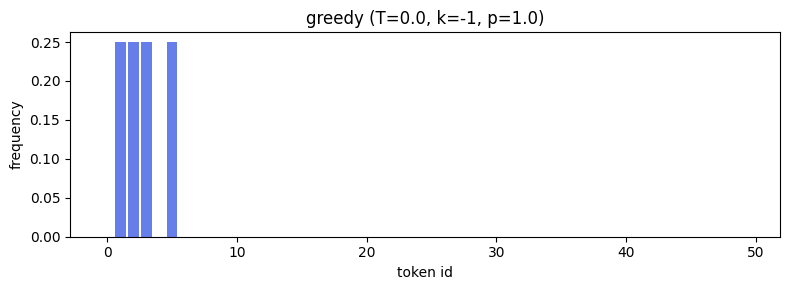

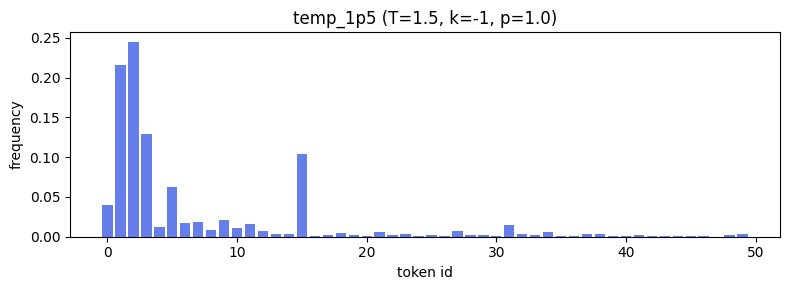

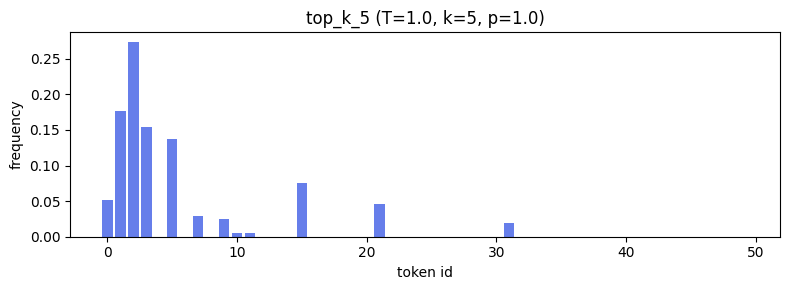

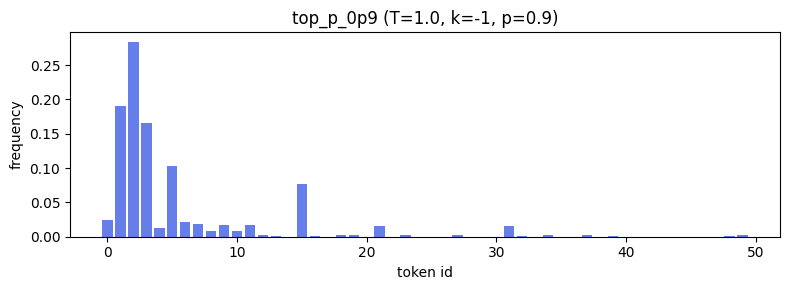

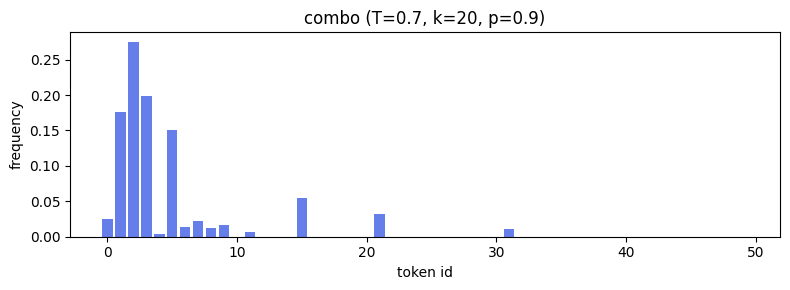

In [10]:
# 1. Запускаем сбор статистики по разным стратегиям семплинга
results = demo_sampling_behavior()

# 2. Визуализируем результаты для каждой стратегии
for label, data in results.items():
    plot_distribution(data["freq"], title=f"{label} (T={data['params'].temperature}, k={data['params'].top_k}, p={data['params'].top_p})")
    plt.show()

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-testy-i-invarianty" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">🧪</span> Тесты и инварианты
</h2>

- Greedy выбирает <code>argmax</code>.
- <code>top‑k</code> оставляет не больше <em>k</em> и не меньше <em>min_tokens_to_keep</em>.
- <code>top‑p</code> перенормирует строки до суммы 1.
- <code>ignore_eos</code> исключает EOS из выборов.
- Выходные индексы — <code>int32</code>.

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-demonstraciya" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">🔬</span> Демонстрация
</h2>

Сгенерируйте результаты <code>demo_sampling_behavior()</code> и сравните распределения для разных параметров. Визуализируйте с помощью <code>plot_distribution</code>.

<table style="width: 100%; border-collapse: collapse; margin: 20px 0; border-radius: 12px; overflow: hidden; box-shadow: 0 2px 10px rgba(0,0,0,0.06);">
  <thead>
    <tr style="background: linear-gradient(135deg, #667eea, #764ba2);">
      <th style="padding: 14px 18px; text-align: left; color: white; font-weight: 600; font-size: 0.95em;">Параметры</th>
      <th style="padding: 14px 18px; text-align: left; color: white; font-weight: 600; font-size: 0.95em;">Эффект</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background: #f8f9ff;">
      <td style="padding: 12px 18px; border-bottom: 1px solid #e2e8f0; color: #2d3748;">temperature ↓</td>
      <td style="padding: 12px 18px; border-bottom: 1px solid #e2e8f0; color: #2d3748;">Распределение «остреет», ближе к greedy</td>
    </tr>
    <tr style="background: #ffffff;">
      <td style="padding: 12px 18px; border-bottom: 1px solid #e2e8f0; color: #2d3748;">top‑k ↓</td>
      <td style="padding: 12px 18px; border-bottom: 1px solid #e2e8f0; color: #2d3748;">Меньше кандидатов — выше повторяемость</td>
    </tr>
    <tr style="background: #f8f9ff;">
      <td style="padding: 12px 18px; border-bottom: 1px solid #e2e8f0; color: #2d3748;">top‑p ↓</td>
      <td style="padding: 12px 18px; border-bottom: 1px solid #e2e8f0; color: #2d3748;">Уменьшается ядро — более предсказуемо</td>
    </tr>
  </tbody>
</table>

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-podvodnye-kamni" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">🛡️</span> Подводные камни
</h2>

<div style="background: #fff5f5; border-left: 4px solid #fc8181; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #c53030; margin-bottom: 6px; font-size: 0.95em;">⚠️ Внимание</div>
  <div style="line-height: 1.7;">Не путайте <em>pad</em> и <em>eos</em>: для семплинга важно не выбирать EOS раньше времени (используйте <code>ignore_eos</code>), а паддинги вообще не должны появляться в распределении логитов.</div>
</div>

<div style="background: #fffbeb; border-left: 4px solid #f59e0b; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 12px 0; color: #2d3748;">
  <div style="font-weight: 700; color: #b7791f; margin-bottom: 6px; font-size: 0.95em;">💡 Совет</div>
  <div style="line-height: 1.7;">Для статистических проверок свойств семплинга (например, влияние температуры) повторяйте выбор много раз на фиксированных логитах с фиксированным seed и сравнивайте эмпирические частоты.</div>
</div>

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-voprosy-samoproverki" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">❓</span> Вопросы для самопроверки
</h2>

<div style="background: #fffff0; border: 1px solid #ecc94b40; border-radius: 14px; padding: 24px 28px; margin: 20px 0;">
  <h4 style="color: #975a16; margin: 0 0 14px 0; font-size: 1.1em; font-weight: 700;">🤔 Вопросы для самопроверки</h4>
  <ol style="color: #2d3748; line-height: 2; margin: 0; padding-left: 20px;">
    <li>Почему температура $\tau \to 0$ приводит к greedy‑поведению?</li>
    <li>Чем top‑p принципиально отличается от top‑k при «хвостатых» распределениях?</li>
    <li>Зачем нужна нижняя граница <em>min_tokens_to_keep</em> и чем грозит её отсутствие?</li>
  </ol>
</div>

<div style="text-align: center; margin: 30px 0;">
  <div style="display: inline-block; width: 60px; height: 3px; background: linear-gradient(to right, transparent, #667eea, transparent); border-radius: 2px;"></div>
</div>

<h2 id="section-klyuchevye-vyvody" style="color: #ffffff; font-size: 1.8em; font-weight: 700; border-bottom: 3px solid #667eea; padding-bottom: 12px; margin-top: 40px; margin-bottom: 20px; letter-spacing: -0.01em;">
  <span style="background: linear-gradient(135deg, #667eea, #764ba2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-right: 8px;">📌</span> Ключевые выводы
</h2>

<div style="background: linear-gradient(135deg, rgba(102,126,234,0.08), rgba(118,75,162,0.08)); border: 1px solid rgba(102,126,234,0.25); border-radius: 16px; padding: 30px; margin-top: 30px;">
  <h3 style="color: #667eea; margin: 0 0 18px 0; font-size: 1.3em; font-weight: 700;">🎯 Ключевые выводы</h3>
  <ul style="color: #ffffff; line-height: 2; list-style: none; padding: 0; margin: 0;">
    <li style="padding: 6px 0; border-bottom: 1px solid rgba(102,126,234,0.1);">✅ Температура управляет «остротой» распределения и в пределе сводится к greedy.</li>
    <li style="padding: 6px 0; border-bottom: 1px solid rgba(102,126,234,0.1);">✅ Top‑k фиксирует число кандидатов, top‑p — их суммарную вероятность.</li>
    <li style="padding: 6px 0;">✅ Реализация согласована с <code>NanoInfer</code> и покрыта тестами инвариантов.</li>
  </ul>
</div>

<div style="text-align: center; padding: 30px 20px; margin-top: 40px; border-top: 2px solid #e2e8f0; color: #718096; font-size: 0.85em;">
  <p style="margin: 0 0 8px 0;">📘 <strong style="color: #667eea;">CookBook Series</strong> — Урок 2 — Семплинг: temperature, top‑k, top‑p</p>
  <p style="margin: 0;">Обратная связь приветствуется</p>
</div>